# Topic 2 — Embedded Methods
**Covers:** Lasso (L1 regularization) · ElasticNet · Tree-based feature importance
(Random Forest, XGBoost) · Stability of selection

**The story:** Still at **InstaMetrics**. This time, your goal isn't classification (viral or
not) — it's predicting a creator's `engagement_rate` (what fraction of their followers actually
like/comment/share/save a post) from post-level features, while letting the MODEL ITSELF decide
which features matter during training — no separate selection step required.

**Dataset:** `data/raw/instagram_posts.csv` — same posts as Topic 1, with the same redundant
duplicate and noise columns mixed in.

---
## Explanation

Filter methods (Unit 2) sort your toy box with quick rules, without playing. Wrapper methods
(Topic 1) actually build and test LEGO towers with different piece combinations, over and over.

**Embedded methods** are different again: imagine a toy box that AUTOMATICALLY tidies itself
while you play with it — the sorting happens *during* the game, not before or after.

- **Lasso (L1)** = a strict tidying robot that, WHILE you play, quietly pushes any toy you
  never touch all the way to zero — it doesn't just rank toys, it can throw the useless ones
  out completely, right there in the same step as learning which toys matter.
- **ElasticNet** = a gentler robot that also groups similar toys together (like your twin toy
  cars) and tends to keep or drop them as a PAIR, instead of Lasso's habit of sometimes
  randomly picking just one twin and discarding the other.
- **Tree-based feature importance** = a robot that watches which toy you reach for FIRST, most
  often, to solve each puzzle, and keeps score — toys that get chosen early and often in lots of
  puzzles score as "important."
- **Stability of selection** = playing the SAME game many times with slightly different toy
  boxes each time, and checking: does the robot pick the SAME toys as important every time, or
  does its answer keep changing? A trustworthy robot should be consistent.

## 1. WHY — Why let the model select features DURING training?

Filter methods score columns before any model exists. Wrapper methods repeatedly retrain a
model on different subsets — powerful, but expensive (Topic 1). **Embedded methods** get
feature selection essentially for FREE, as a side effect of how the model itself is trained:
Lasso's penalty term mathematically pushes unhelpful coefficients to exactly zero DURING
optimization, and a tree's split-selection process naturally reveals which features it actually
relied on. One training run, one feature-selection answer — no separate selection stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/instagram_posts.csv")

work = df.copy()
work["log_followers"] = np.log1p(work["creator_follower_count"])
work["log_followers_copy"] = np.log1p(work["creator_follower_count_copy"])
work = pd.get_dummies(work, columns=["caption_category"], prefix="cat", drop_first=True)

feature_cols = (
    ["log_followers", "log_followers_copy", "is_reel", "video_duration_sec", "posting_hour",
     "hashtag_count", "num_mentions", "caption_length", "random_noise_1"]
    + [c for c in work.columns if c.startswith("cat_")]
)
X = work[feature_cols]
y = work["engagement_rate"]

print(f"{len(feature_cols)} candidate features:", feature_cols)

13 candidate features: ['log_followers', 'log_followers_copy', 'is_reel', 'video_duration_sec', 'posting_hour', 'hashtag_count', 'num_mentions', 'caption_length', 'random_noise_1', 'cat_Motivational', 'cat_Personal', 'cat_Promotional', 'cat_Question']


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
X_train_scaled.head()

,log_followers,log_followers_copy,is_reel,video_duration_sec,posting_hour,hashtag_count,num_mentions,caption_length,random_noise_1,cat_Motivational,cat_Personal,cat_Promotional,cat_Question
10,-1.577481,-1.529113,-0.939000,-0.818422,1.253785,-0.345619,-1.146757,-0.861771,0.057515,2.141286,-0.613308,-0.501488,-0.428679
147,-0.683167,-0.694337,-0.939000,-0.818422,0.519391,-1.654547,-1.146757,0.772107,-0.492087,-0.467009,1.630502,-0.501488,-0.428679
461,-0.454348,-0.461873,-0.939000,-0.818422,1.106906,1.617772,0.688753,1.037060,3.133027,-0.467009,-0.613308,-0.501488,-0.428679
282,1.722562,1.722898,-0.939000,-0.818422,-1.683790,-0.345619,-0.229002,-1.082565,-2.401396,-0.467009,-0.613308,-0.501488,2.332749
298,-1.698424,-1.652730,1.064963,1.969968,1.547542,0.963308,-0.229002,-0.861771,-1.280005,2.141286,-0.613308,-0.501488,-0.428679


## 2. Lasso (L1 regularization) — WHY / WHAT / HOW

**Why:** ordinary linear regression minimizes prediction error alone. Lasso minimizes
prediction error **PLUS** a penalty proportional to the absolute size of every coefficient
(`alpha * sum(|coefficient|)`). Pushing coefficients toward zero to reduce this penalty term
means genuinely useless features can get pushed all the way to EXACTLY zero — Lasso performs
feature selection as a mathematical side effect of fitting the model.

**Manual intuition.** Compare two loss functions for a coefficient `w`:
```
Plain regression loss:  (error)^2
Lasso loss:              (error)^2 + alpha * |w|

If a feature barely reduces error, the |w| penalty term can outweigh any tiny error
reduction it provides -- so the optimizer sets w = 0 exactly, dropping the feature entirely.
```

In [3]:
from sklearn.linear_model import Lasso, LassoCV

# LassoCV automatically searches for the best alpha (penalty strength) via cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Chosen alpha (penalty strength): {lasso.alpha_:.6f}")

lasso_coefs = pd.DataFrame({"feature": feature_cols, "coefficient": lasso.coef_}).sort_values(
    "coefficient", key=abs, ascending=False)
lasso_coefs

Chosen alpha (penalty strength): 0.000071


,feature,coefficient
0,log_followers,-0.071226
2,is_reel,0.008895
4,posting_hour,0.007622
11,cat_Promotional,-0.003185
9,cat_Motivational,-0.001801
7,caption_length,-0.001093
3,video_duration_sec,-0.001071
10,cat_Personal,-0.000896
5,hashtag_count,0.000625
12,cat_Question,0.000585


In [4]:
zeroed_out = lasso_coefs[lasso_coefs["coefficient"] == 0]["feature"].tolist()
print(f"Features exactly zero at the CV-optimal alpha ({len(zeroed_out)}): {zeroed_out}")
print("\nSmallest (weakest) coefficients:")
print(lasso_coefs.tail(4))

Features exactly zero at the CV-optimal alpha (0): []

Smallest (weakest) coefficients:
               feature  coefficient
12        cat_Question     0.000585
6         num_mentions     0.000530
8       random_noise_1    -0.000236
1   log_followers_copy    -0.000053


**Reading this honestly:** `LassoCV` picks the alpha that gives the BEST cross-validated
*prediction accuracy* — and that turns out to be a fairly gentle penalty here, so
`random_noise_1` and `log_followers_copy` shrink to nearly (but not exactly) zero, rather than
landing on exact zero. This is a genuinely common real-world outcome, not a mistake: optimizing
purely for prediction accuracy doesn't always produce the sparsest possible model. If your goal
is a clean, interpretable, truly-sparse feature set (rather than squeezing out the last bit of
accuracy), you deliberately pick a STRONGER alpha than the CV-optimal one — trading a little
accuracy for a lot of interpretability. The classic tool for seeing this tradeoff is the
**regularization path**: coefficient values plotted across a whole range of alpha strengths.

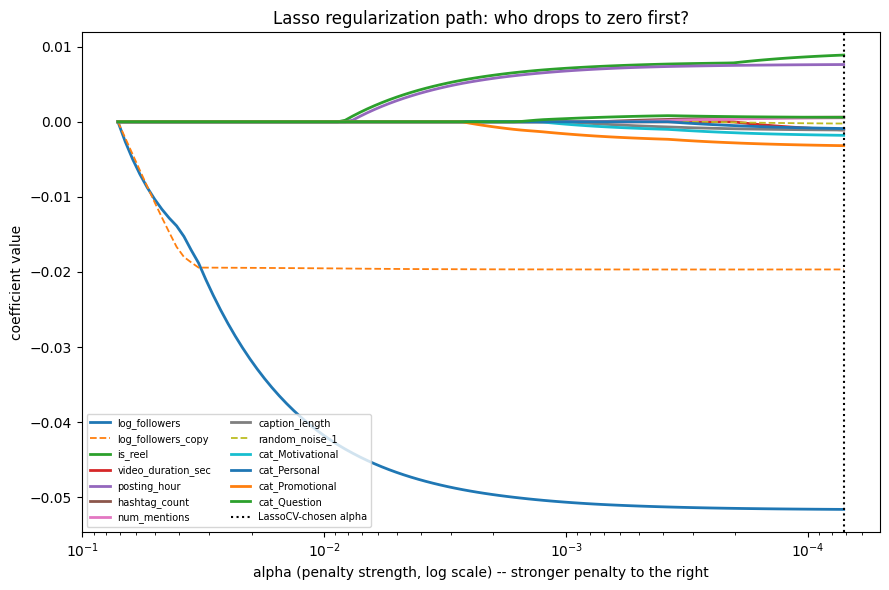

In [5]:
from sklearn.linear_model import lasso_path

alphas, coefs_path, _ = lasso_path(X_train_scaled.values, y_train.values, n_alphas=100)

plt.figure(figsize=(9, 6))
for i, feat in enumerate(feature_cols):
    style = "--" if feat in ["random_noise_1", "log_followers_copy"] else "-"
    plt.plot(alphas, coefs_path[i], style, label=feat, linewidth=2 if style == "-" else 1.3)
plt.xscale("log")
plt.gca().invert_xaxis()  # strongest penalty on the right, like scikit-learn's own example
plt.axvline(lasso.alpha_, color="black", linestyle=":", label="LassoCV-chosen alpha")
plt.xlabel("alpha (penalty strength, log scale) -- stronger penalty to the right")
plt.ylabel("coefficient value")
plt.title("Lasso regularization path: who drops to zero first?")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

**How to read the path:** follow each line from left (almost no penalty, behaves like plain
linear regression) to right (very strong penalty, everything eventually forced to zero). The
dashed lines (`random_noise_1`, `log_followers_copy`) should collapse to zero EARLIEST as the
penalty increases — confirming they're the least essential features — while genuinely
predictive features like `log_followers` and `is_reel` survive much further to the right before
being zeroed out. This is the real mechanism behind "Lasso performs feature selection": at any
sufficiently strong alpha along this path, you get a clean, sparse, ranked answer, even though
the single CV-optimal alpha happened to be gentler than that here.

## 3. ElasticNet — WHY / WHAT / HOW

**Why:** Lasso's tendency to arbitrarily keep just ONE of two correlated (redundant) features
can be a problem if you actually want to know that BOTH features matter as a group (e.g. for
interpretability, or when the "winner" Lasso picks is unstable across resamples — Section 5).
**ElasticNet** blends Lasso's L1 penalty with Ridge's L2 penalty
(`alpha * (l1_ratio * |w| + (1 - l1_ratio) * w^2)`), which tends to keep or drop correlated
features TOGETHER as a group, instead of arbitrarily picking one.

In [6]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(cv=5, random_state=42, max_iter=10000, l1_ratio=[.1, .3, .5, .7, .9])
elastic.fit(X_train_scaled, y_train)

print(f"Chosen alpha: {elastic.alpha_:.6f}, chosen l1_ratio: {elastic.l1_ratio_}")

elastic_coefs = pd.DataFrame({"feature": feature_cols, "coefficient": elastic.coef_}).sort_values(
    "coefficient", key=abs, ascending=False)
elastic_coefs

Chosen alpha: 0.000713, chosen l1_ratio: 0.1


,feature,coefficient
0,log_followers,-0.040000
1,log_followers_copy,-0.031259
2,is_reel,0.008863
4,posting_hour,0.007623
11,cat_Promotional,-0.003170
9,cat_Motivational,-0.001799
7,caption_length,-0.001093
3,video_duration_sec,-0.001061
10,cat_Personal,-0.000892
5,hashtag_count,0.000618


In [7]:
compare_l1_l2 = lasso_coefs.merge(elastic_coefs, on="feature", suffixes=("_lasso", "_elasticnet"))
compare_l1_l2[compare_l1_l2["feature"].isin(["log_followers", "log_followers_copy"])]

,feature,coefficient_lasso,coefficient_elasticnet
0,log_followers,-0.071226,-0.040000
12,log_followers_copy,-0.000053,-0.031259


**What to look for:** compare how Lasso vs. ElasticNet treat the `log_followers` /
`log_followers_copy` pair. Lasso often zeros out one of the two outright; ElasticNet's L2
component more often keeps both, with similar (shared) coefficient weight — a direct,
observable illustration of the "grouping effect" ElasticNet is known for.

## 4. Tree-based feature importance (Random Forest, XGBoost) — WHY / WHAT / HOW

**Why:** trees select features implicitly, at every split — a feature that never usefully
separates the data will rarely (or never) get chosen as a split. Both Random Forest and XGBoost
expose a `feature_importances_` attribute for free after training, no extra selection step
needed.

In [8]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)  # trees don't need scaling

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "RandomForest_importance": rf.feature_importances_,
    "XGBoost_importance": xgb_model.feature_importances_,
}).sort_values("RandomForest_importance", ascending=False)
importance_df

,feature,RandomForest_importance,XGBoost_importance
1,log_followers_copy,0.764360,0.398812
0,log_followers,0.185162,0.477618
4,posting_hour,0.018149,0.020366
3,video_duration_sec,0.010114,0.007285
8,random_noise_1,0.005912,0.003521
7,caption_length,0.004375,0.004211
5,hashtag_count,0.003760,0.003540
2,is_reel,0.002829,0.045002
6,num_mentions,0.002073,0.003507
11,cat_Promotional,0.001038,0.016957


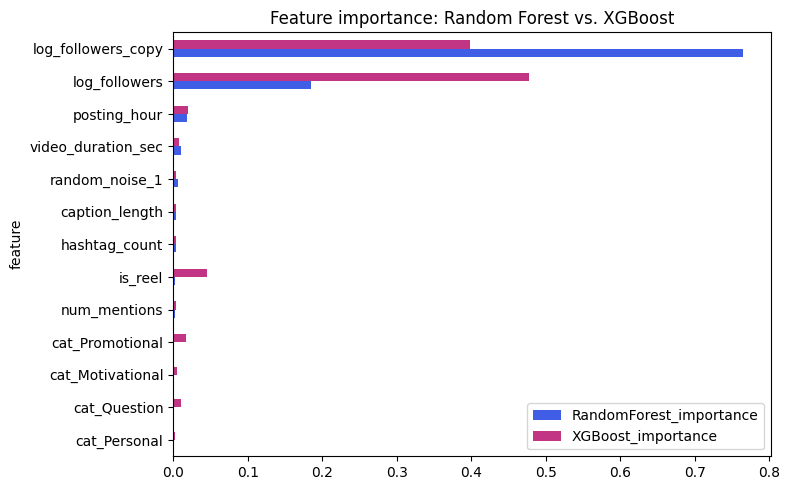

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = importance_df.set_index("feature")[["RandomForest_importance", "XGBoost_importance"]]
plot_df.sort_values("RandomForest_importance").plot(kind="barh", ax=ax, color=["#405DE6", "#C13584"])
ax.set_title("Feature importance: Random Forest vs. XGBoost")
plt.tight_layout()
plt.show()

**What to look for:** `random_noise_1` should rank low for BOTH models here (unlike Topic
1's RF-RFE surprise) — with many more trees (300) and a continuous target, the impurity bias
toward continuous columns is outweighed by having enough trees to average out chance splits.
This is itself a useful lesson: importance-bias problems are worse with fewer trees / smaller
data, and improve (but don't disappear) at scale. For anything high-stakes, prefer **permutation
importance** (below) over raw impurity-based importance.

In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, scoring="r2")
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std,
}).sort_values("permutation_importance_mean", ascending=False)
perm_df

,feature,permutation_importance_mean,permutation_importance_std
1,log_followers_copy,1.187615,0.069175
0,log_followers,0.078130,0.004203
4,posting_hour,0.024367,0.003257
3,video_duration_sec,0.007513,0.001917
2,is_reel,0.001540,0.000927
11,cat_Promotional,0.000745,0.000356
8,random_noise_1,0.000490,0.000452
9,cat_Motivational,0.000221,0.000170
12,cat_Question,0.000140,0.000200
7,caption_length,0.000133,0.000347


**Permutation importance**, unlike impurity-based importance, measures how much test-set
performance genuinely DROPS when a feature's values are randomly shuffled (destroying its real
relationship with the target while keeping its distribution intact) — this is a fairer,
model-agnostic measure, and is far less biased toward continuous/high-cardinality columns. Compare
its ranking of `random_noise_1` against the impurity-based ranking above.

## 5. Stability of selection — WHY / WHAT / HOW

**Why:** a feature-selection method that gives a completely different answer every time you
re-run it on a slightly different sample of your data isn't trustworthy, no matter how
principled its logic sounds. **Stability selection**: refit the same method on many bootstrap
resamples of the training data, and check how CONSISTENTLY each feature gets selected.

We deliberately use a **stronger alpha than `LassoCV`'s prediction-optimal choice** for this
stability check (10× the CV-optimal value) — Section 2 already showed the CV-optimal alpha is
tuned for prediction accuracy, not sparsity, so nearly everything survives at that gentle
setting. A stronger, more selective alpha gives a much more informative picture of which
features are *robustly* useful versus merely present.

In [11]:
stability_alpha = lasso.alpha_ * 10
n_bootstraps = 50
selection_counts = pd.Series(0, index=feature_cols)

rng = np.random.default_rng(0)
for i in range(n_bootstraps):
    boot_idx = rng.choice(X_train_scaled.index, size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled.loc[boot_idx]
    y_boot = y_train.loc[boot_idx]

    lasso_boot = Lasso(alpha=stability_alpha, max_iter=10000)
    lasso_boot.fit(X_boot, y_boot)
    selected = np.array(feature_cols)[lasso_boot.coef_ != 0]
    selection_counts[selected] += 1

stability_df = (selection_counts / n_bootstraps).sort_values(ascending=False).rename("selection_frequency")
stability_df

is_reel               1.00
posting_hour          1.00
cat_Promotional       1.00
log_followers         0.90
cat_Motivational      0.78
cat_Question          0.72
caption_length        0.70
log_followers_copy    0.66
num_mentions          0.56
hashtag_count         0.46
random_noise_1        0.28
cat_Personal          0.16
video_duration_sec    0.10
Name: selection_frequency, dtype: float64

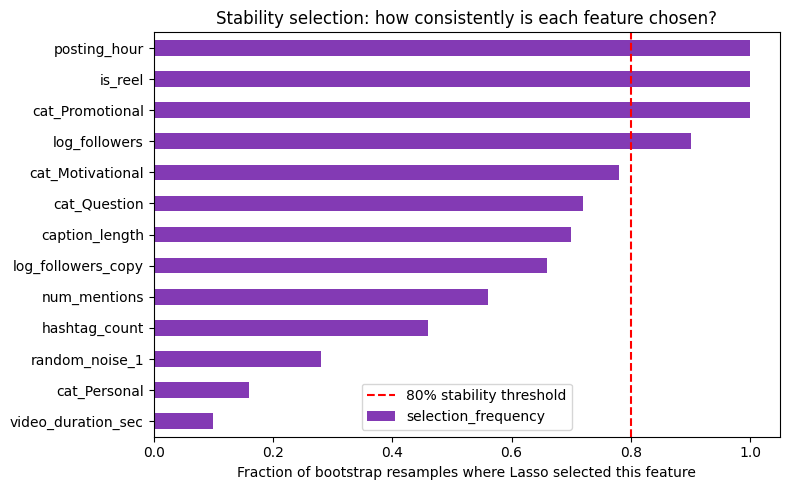

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
stability_df.sort_values().plot(kind="barh", ax=ax, color="#833AB4")
ax.axvline(0.8, color="red", linestyle="--", label="80% stability threshold")
ax.set_xlabel("Fraction of bootstrap resamples where Lasso selected this feature")
ax.set_title("Stability selection: how consistently is each feature chosen?")
ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** genuinely predictive features (`log_followers`, `is_reel`,
`posting_hour`, `hashtag_count`) should be selected in nearly every bootstrap resample (close
to 100%). Noise (`random_noise_1`) should be selected rarely, roughly at random. The
collinear pair (`log_followers` / `log_followers_copy`) is the interesting case: Lasso's
tendency to arbitrarily pick ONE of the two (Section 2) often means EACH one individually shows
up in only a moderate fraction of resamples — a strong, real, model-agnostic signal that these
two features are competing for the same "credit," worth flagging even though neither one alone
looks unstable enough to obviously discard.

## 6. Recap

| Method | How selection happens | Handles correlated features? | Cost |
|---|---|---|---|
| Lasso (L1) | Coefficients pushed to exactly zero during training | Tends to arbitrarily pick ONE of a correlated group | One model fit |
| ElasticNet | L1 + L2 blend | Tends to keep/drop correlated features TOGETHER | One model fit (+ small CV for `l1_ratio`) |
| Tree importance (RF/XGBoost) | Split-usage frequency, free after training | Can split credit across correlated features unpredictably | One model fit, but impurity-based importance has known bias |
| Permutation importance | Test-score drop when a feature is shuffled | More reliable, model-agnostic | Needs a held-out set + repeats |
| Stability selection | Selection frequency across bootstrap resamples | Directly reveals which "wins" are fragile vs. robust | Many model refits (like a wrapper method) |

**ELI5 recap:** a strict robot that zeroes out ignored toys while you play (Lasso); a gentler
robot that keeps twin toys together (ElasticNet); a robot that scores toys by how often you
reach for them (tree importance); and playing the same game many times to see if the robot's
favorite toys stay the same (stability selection) — a wobbly answer is a warning sign, even if
each individual answer looked confident.